In [1]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 84 (delta 27), reused 32 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 3.15 MiB | 7.08 MiB/s, done.
Resolving deltas: 100% (27/27), done.


In [2]:
# local files
from src import utils
from src.synthetic_dataset import SyntheticEllipseDataset
from src.resunet import ResUNet

import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
# Carregando os dados: BBBC038
# Verifica se a pasta já não existe antes de baixar
if not os.path.exists('./data/stage1_train'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
    !cd data && unzip -q stage1_train.zip -d stage1_train

--2026-09-06 17:56:57--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82923446 (79M) [application/zip]
Saving to: ‘./data/stage1_train.zip’

stage1_train.zip    100%[===================>]  79.08M  23.3MB/s    in 3.4s    

2026-09-06 17:57:01 (23.3 MB/s) - ‘./data/stage1_train.zip’ saved [82923446/82923446]



In [5]:
import os
from pathlib import Path
import numpy as np
import torch
from skimage.io import imread
from skimage.transform import resize

IMG_SIZE = 128

class BBBC038Dataset(Dataset):
    def __init__(self):
        self.train_dir = Path("data/stage1_train")
        self.ids = os.listdir(self.train_dir)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id = self.ids[idx]
        self.mask_dir = self.train_dir / id / "masks"
        img_path = self.train_dir / id / "images" / f"{id}.png"
        image = imread(img_path)[..., :3] / 255
        masks = [imread(self.mask_dir / f) for f in os.listdir(self.mask_dir)]
        mask = np.max(masks, axis=0) / 255

        image = resize(image, (IMG_SIZE, IMG_SIZE), preserve_range=True)
        mask = resize(mask, (IMG_SIZE, IMG_SIZE), order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)

        image = torch.from_numpy(image).permute(2, 0, 1).contiguous().float()
        mask = torch.from_numpy(mask[..., None]).permute(2, 0, 1)[0].contiguous().float()

        return image, mask

In [6]:
dataset = BBBC038Dataset()
train_dataset, val_dataset, test_dataset = random_split(dataset, [0.7, 0.15, 0.15])

In [7]:
# Treinando a ResUNet no BBBC038

model = ResUNet(3, 1).to(device)

loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

model.train()
for epoch in range(5):
    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)

        y_hat = model(X).squeeze(1)
        loss = loss_fn(y_hat, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 5 == 0:
            print(f'{epoch}/{batch} - loss={loss}')

0/0 - loss=0.6983768939971924
0/5 - loss=0.6118775010108948
0/10 - loss=0.5932343602180481
0/15 - loss=0.5580593347549438
0/20 - loss=0.46137627959251404
0/25 - loss=0.4547659754753113
1/0 - loss=0.3966013193130493
1/5 - loss=0.33866995573043823
1/10 - loss=0.2888266444206238
1/15 - loss=0.32110798358917236
1/20 - loss=0.2594248056411743
1/25 - loss=0.3022378087043762
2/0 - loss=0.22797241806983948
2/5 - loss=0.23971262574195862
2/10 - loss=0.31237292289733887
2/15 - loss=0.24130305647850037
2/20 - loss=0.23534457385540009
2/25 - loss=0.19423556327819824
3/0 - loss=0.28974801301956177
3/5 - loss=0.22792597115039825
3/10 - loss=0.23202773928642273
3/15 - loss=0.2352478802204132
3/20 - loss=0.14729969203472137
3/25 - loss=0.21452540159225464
4/0 - loss=0.15042051672935486
4/5 - loss=0.1676061749458313
4/10 - loss=0.15104374289512634
4/15 - loss=0.1583063304424286
4/20 - loss=0.16690857708454132
4/25 - loss=0.177132248878479


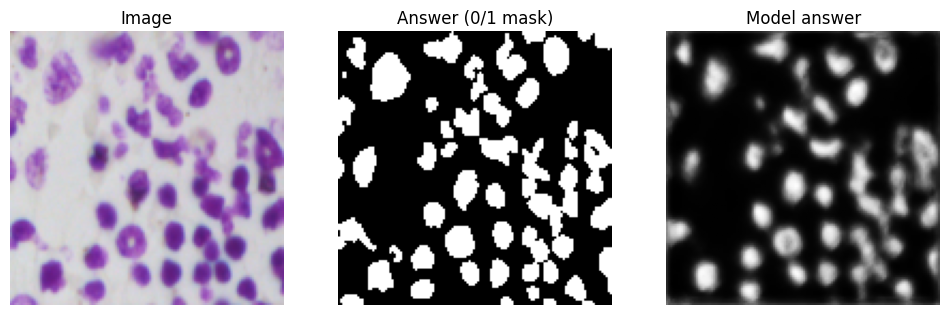

In [8]:
# Verificando a saída do modelo

model.eval()

for img, mask in DataLoader(test_dataset, shuffle=True):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))[0,0].cpu().detach().numpy()
    img = img[0].permute(1, 2, 0).cpu().detach().numpy()
    mask = mask[0].cpu().detach().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Answer (0/1 mask)")
    axes[1].axis("off")

    axes[2].imshow(y, cmap="gray")
    axes[2].set_title("Model answer")
    axes[2].axis("off")


    plt.show()

    break

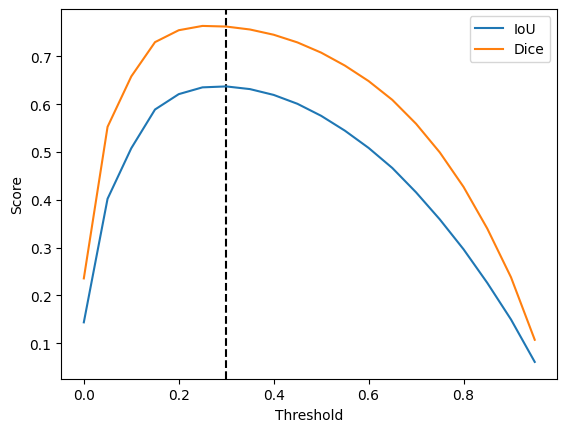

IoU final: 0.6315402984619141
Dice final: 0.7567413449287415


In [20]:
# computa o IoU e Dice no conjunto de validação/teste

model.eval()

def pred(x):
    return torch.sigmoid(model(x.to(device)))[0].cpu()

thresholds = torch.arange(0, 1, .05)

with torch.no_grad():
    # encontra o melhor limiar com o conjunto de validação
    iou_scores, dice_scores = [], []
    for x, y in DataLoader(val_dataset, pin_memory=True):
        y_hat = pred(x)
        iou_scores.append([float(utils.iou_score(1 * (y_hat > th), y)) for th in thresholds])
        dice_scores.append([float(utils.dice_score(1 * (y_hat > th), y)) for th in thresholds])

    iou_scores = torch.tensor(iou_scores).mean(dim=0)
    dice_scores = torch.tensor(dice_scores).mean(dim=0)
    best_threshold = thresholds[iou_scores.argmax()]

    plt.axvline(best_threshold, color='k', linestyle='--')
    plt.plot(thresholds, iou_scores, label='IoU')
    plt.plot(thresholds, dice_scores, label='Dice')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.show()

    # computa o IoU e Dice pontuais no conjunto de teste
    iou_scores_test, dice_scores_test = [], []
    for x, y in DataLoader(test_dataset, pin_memory=True):
        y_hat = pred(x)
        iou_scores_test.append(float(utils.iou_score(1 * (y_hat > best_threshold), y)))
        dice_scores_test.append(float(utils.dice_score(1 * (y_hat > best_threshold), y)))

    final_iou_score = torch.tensor(iou_scores_test).mean().item()
    final_dice_score = torch.tensor(dice_scores_test).mean().item()

    print("IoU final:", final_iou_score)
    print("Dice final:", final_dice_score)